<a href="https://colab.research.google.com/github/ceremona/Prospector/blob/main/prospector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Popper-Prospector

A teaching-scale reimplementation of the decision loop in **Mern, Corso, Burch, House & Caers (2024), Intelligent Prospector v2.0** (arXiv:2410.10610), motivated by **Caers (2025), The Future of AI in Critical Mineral Exploration** (arXiv:2512.02879).

**What it does:** generates synthetic geology, keeps a Bayesian belief over competing hypotheses, drills where expected information gain is highest, tests a max-entropy null hypothesis for falsification, compares against grid drilling, and ablates three likelihood families. Metrics go to BigQuery if you want them to.

**Honest scope (read this first):** full POMDP + SARSOP is out of scope. The belief is reduced to the hypothesis layer (no domain-geometry sampling) and the planner is myopic. That is deliberate: tractable, transparent, and it teaches the loop. The paper itself validates on synthetic ground truths (17 of them), because a drilling policy can only be scored against a truth you know - simulation is where the answer key is free. This notebook inherits that honestly, and Step 9c stress-tests what happens when the model's shape assumptions are wrong.

**Also honest:** no gradients, no training, no variational anything. The belief update is exact Bayes on four numbers; the planner is brute-force scoring of candidate cells; randomness is PCG64 (passes the TestU01 Big Crush battery) - the limitation of this notebook is not the quality of the random numbers, it is that the probability model is fiction. Step 13 says what to do about that.

## Mapping to the two papers

**Paper 1 (Intelligent Prospector v2.0):**
- Hierarchical belief -> posterior over 4 hypotheses (their hierarchy also has a geometry layer sampled by MCMC; we cut it)
- POMDP -> plan / drill / observe / update loop ('partial' means partially observable: you never see the whole geological state, only noisy spot checks)
- Bayesian belief update -> update_posterior (theirs uses kriging likelihoods + elliptical slice sampling in Turing.jl; ours is closed-form Gaussians)
- SARSOP solver -> myopic Monte-Carlo EVOI planner (one-step lookahead; theirs optimizes an economic reward and shows uncertainty reduction falls out of it - we hard-code information gain as the objective, which is the sharpest philosophical divergence)
- Null-hypothesis falsification -> null_loglik vs human_loglik
- Grid-drilling baseline -> run_grid (36 holes, like them)

**Paper 2 (Caers 2025):**
- Popper-Bayes method -> priors + update + falsify (the reading is the only channel through which reality touches the belief)
- Variance restoration -> ensemble sampling, not deterministic interpolation; and the noise-convolution fix in Step 4 is this principle applied to our own port
- AI generates competing hypotheses -> the H0..H3 set
- Human-in-the-loop data acquisition -> EVOI chooses where to spend budget
- Step 9c (not in the papers): a likelihood-family ablation that tests Paper 2's central claim - thin-tailed scoring of a heavy-tailed world manufactures false certainty

**Where we deliberately diverge from the paper, in one pass:** hypotheses here are graben-presence x geochemical-domain (a 2x2 factorial, including a no-graben story the paper does not have); theirs vary the *counts* of grabens (1-2) and domains (1-2), and drilling observes the domain directly (a deterministic readout - ours must infer domains from grade values alone). Grid is 20x20 with RBF-like texture; theirs is 32x32 Matern with marginal std 0.1 and measurement noise 0.001 - so tiny that omitting the noise convolution is harmless in their regime, and fatal in ours (see Step 4).

## Step 0 - dependencies

Colab ships everything below, but this cell exists for portability: every library actually used is installed explicitly (earlier drafts forgot matplotlib and google-cloud-bigquery), and %pip - unlike !pip - installs into the kernel's own environment rather than a subprocess shell.

In [1]:
# %pip (not !pip) installs into this notebook kernel's environment.
# Everything used anywhere below is listed, so the notebook also runs
# unchanged outside Colab (local Jupyter, a containerized Cloud Run job).
%pip -q install numpy scipy pandas matplotlib plotly google-cloud-bigquery
print('dependencies ready')

dependencies ready


## Step 1 - configuration and imports

Every tunable lives here, and ALL imports happen here (an earlier draft imported plotly ten cells late, so a failed install surfaced late). Keep the grid small: the full experience - sweep, ablation, falsification - runs on free CPU in a few minutes.

Naming honesty: DECISION_CONF is a *confidence* threshold (max posterior probability), not an entropy - an earlier draft called it ENTROPY_STOP, which was misleading.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go     # used in Step 11; imported here so a
                                      # missing install surfaces now, not late
from scipy.ndimage import gaussian_filter
from scipy.stats import norm
from scipy.special import logsumexp   # used by the empirical likelihood, 9c

# --- world configuration ---
GRID = 20            # 20x20 lattice of candidate drilling cells (400 max)
TRIALS = 12          # independent synthetic truths in the Step 9 sweep
ENSEMBLE = 24        # fake geological realizations per hypothesis; their
                     # per-cell spread is the ALEATORIC (irreducible) term
MC = 4               # simulated readings per candidate cell in the planner
                     # (a statistical sampling count; 'MC' here is not the
                     # method name 'Monte Carlo' - same letters, two meanings)
CANDIDATES = 60      # how many remaining cells the planner scores per hole
DECISION_CONF = 0.90 # max posterior probability that locks the go/no-go.
                     # Calibration promise: '90 percent sure' only MEANS 90
                     # percent right if every model assumption actually holds.

# --- observation model ---
NOISE_T = 0.5        # drill-hole thickness measurement error (std, assumed
                     # KNOWN - real systems estimate it from twin holes)
NOISE_G = 0.15       # grade measurement error (std, also assumed known)
SEED = 7             # reproducibility dial. Fixed seeds are a scientific
                     # virtue here, not a weakness: PCG64 passes the TestU01
                     # Big Crush battery, so pseudorandom quality is not
                     # the bottleneck - the fictional probability model is.

print('config set')

config set


## Step 2 - synthetic geology (the ground truth generator)

A hypothesis is a parameter set, not a model you fit. sample_field draws one realization. Smoothed white noise stands in for a Gaussian process draw.

Three honesty notes, stated here so the README writes itself:

1. gaussian_filter on white noise induces an RBF-like (squared-exponential) covariance, not the Matern kernel the paper uses. Defensible at teaching scale - claim nothing stronger.
2. The hypothesis set diverges from the paper's on purpose: ours is a 2x2 factorial of graben-presence x geochemical domain (including a no-graben story the paper does not have); theirs varies the *counts* of grabens and domains. Ours is easier to reason about; theirs is richer.
3. Everything here is synthetic. That is a feature for validating a decision loop (you get the answer key) and a limitation for claiming anything about geology. The upgrade path - a free, public-domain, real exhaustive dataset (Walker Lake) that slots in exactly where this generator sits - is described in Step 13.

In [3]:
def sample_field(params, seed):
    # Draw one realization of a geological field for a given hypothesis.
    # Returns (thickness, grade) arrays on a GRID x GRID lattice.
    # NOTE: Step 9c redefines this function with a regime switch
    # (WORLD_HEAVY_TAILS); with the switch off it is numerically identical
    # to this version, so nothing downstream changes behavior.
    rng = np.random.default_rng(seed)
    # Smoothed white noise stands in for a GP draw: the filter induces an
    # RBF-like spatial covariance (NOT Matern - see the markdown above).
    base_t = gaussian_filter(rng.standard_normal((GRID, GRID)), sigma=2.0)
    base_g = gaussian_filter(rng.standard_normal((GRID, GRID)), sigma=2.0)
    thickness = params['t_mean'] + 1.5 * base_t
    grade = params['g_mean'] + 0.3 * base_g
    if params.get('graben', False):
        # A graben: a linear trough that thickens the host rock (+4) and
        # enriches grade (+0.4). Orientation is fixed by 'slope'; all
        # hypotheses share one orientation, and Step 10's novel truth
        # deliberately uses a different one.
        yy, xx = np.mgrid[0:GRID, 0:GRID]
        slope = params.get('slope', 0.6)
        dist = np.abs(xx - slope * yy - GRID * 0.5) / np.sqrt(1.0 + slope**2)
        graben = np.exp(-(dist**2) / (2.0 * 2.5**2))
        thickness = thickness + 4.0 * graben
        grade = grade + 0.4 * graben
    return thickness, grade

# The human hypothesis set: graben-presence x geochemical domain, 2x2 = 4.
# The paper's set instead varies the COUNT of grabens (1-2) and domains
# (1-2), and its drilling observes domain membership directly; ours must
# infer domains from grade values alone - part of why ours needs more holes.
HYPOTHESES = [
    {'name': 'H0: no graben, domain A', 'graben': False, 't_mean': 6.0, 'g_mean': 0.6},
    {'name': 'H1: no graben, domain B', 'graben': False, 't_mean': 6.0, 'g_mean': 1.2},
    {'name': 'H2: graben, domain A',    'graben': True,  't_mean': 6.0, 'g_mean': 0.6},
    {'name': 'H3: graben, domain B',    'graben': True,  't_mean': 6.0, 'g_mean': 1.2},
]
print(len(HYPOTHESES), 'hypotheses defined')

4 hypotheses defined


## Step 3 - build predictive ensembles

For each hypothesis we precompute an ensemble of fake worlds. This is the model-implied predictive distribution - and it is where variance is *preserved* rather than smoothed away, the point Paper 2 hammers. The ensembles are drawn once and frozen; their per-cell spread is the aleatoric term consumed by every likelihood below.

Cost of the freeze, stated plainly: 24 members means each per-cell width carries roughly 15 percent relative estimation error, which propagates into every tail score. And nothing about these bell curves ever updates - the notebook is Bayesian at the top layer (which story) and frozen below it (what each story predicts). The paper escapes this partially by resampling geometry with MCMC after every hole; we deleted that layer, so only *which curves you consult* changes as data arrives.

In [4]:
def build_ensembles(hypotheses, n, seed):
    # One list of n realizations per hypothesis. Frozen after this cell: the
    # per-cell mean/std across members is the aleatoric predictive that
    # every likelihood computation below consumes.
    ensembles = []
    for k, h in enumerate(hypotheses):
        members = [sample_field(h, seed * 1000 + k * 100 + m) for m in range(n)]
        ensembles.append(members)
    return ensembles

ensembles = build_ensembles(HYPOTHESES, ENSEMBLE, seed=SEED)
print('ensembles built:', len(ensembles), 'x', ENSEMBLE)

ensembles built: 4 x 24


## Step 4 - observation model and likelihood

A drill hole returns a noisy (grade, thickness). The likelihood of a reading under a hypothesis is a Gaussian fit to that hypothesis' ensemble at the drilled cell, *convolved with measurement noise*: total predictive variance = ensemble variance + noise variance, added in quadrature.

This is the fix for the port's one real statistical bug. An earlier draft used the ensemble spread alone as the observation sd. Harmless in the paper's regime - their measurement noise is 0.001 against a GP std of 0.1, i.e. 0.01 percent of the variance - but fatal in this notebook's regime, where noise (0.5 thickness / 0.15 grade) is the LARGER term. Omitting it inflated z-scores roughly 2-4x, collapsed posteriors too fast, and biased the falsification test toward rejecting the humans. Transplanting a method without rechecking its parameter regime is how that class of bug happens; the fix is Paper 2's variance-honesty principle applied to our own port.

What is fixed vs fitted here (the full inventory lives in Step 13): the SHAPE is assumed (Gaussian; real grade distributions are famously lognormal - Step 9c tests what that costs), the instrument noise is assumed KNOWN, and the geological width is fixed by construction (smoothing scale and amplitude are Step 2 constants that no drilling ever re-estimates).

In [5]:
def observe(truth_T, truth_G, i, j, rng):
    # A drill hole at (i, j): truth + instrument error. The instrument is
    # family-independent in Step 9c's ablation - the SAME readings are
    # re-scored by three different likelihood shapes.
    t = truth_T[i, j] + NOISE_T * rng.standard_normal()
    g = truth_G[i, j] + NOISE_G * rng.standard_normal()
    return g, t

def cell_stats(ensemble, i, j):
    # Ensemble-only mean and spread of thickness and grade at one cell.
    ts = np.array([m[0][i, j] for m in ensemble])
    gs = np.array([m[1][i, j] for m in ensemble])
    return ts.mean(), ts.std(), gs.mean(), gs.std()

def predictive(ensemble, i, j):
    # Predictive distribution of an OBSERVATION at (i, j): ensemble spread
    # (aleatoric geology) + measurement noise, added in quadrature.
    # Returns (mu_t, sd_t, mu_g, sd_g).
    mu_t, sd_t, mu_g, sd_g = cell_stats(ensemble, i, j)
    sd_t = np.sqrt(sd_t**2 + NOISE_T**2) + 1e-6
    sd_g = np.sqrt(sd_g**2 + NOISE_G**2) + 1e-6
    return mu_t, sd_t, mu_g, sd_g

def loglik(g, t, mu_g, sd_g, mu_t, sd_t):
    # Gaussian log-likelihood of one reading under one hypothesis. The
    # penalty for a miss grows roughly with the SQUARE of the miss
    # distance (in sd units) - which is why a wrong claimed spread
    # distorts everything (see the regime-2 spikes in Step 9c).
    return norm.logpdf(g, mu_g, sd_g) + norm.logpdf(t, mu_t, sd_t)

print('likelihood ready')

likelihood ready


## Step 5 - Bayesian belief update

Posterior is proportional to prior times the product of reading likelihoods, computed in log space for numerical stability. The update is incremental: callers pass only the newest reading and let the running log-score carry the history.

What this is, in one sentence each:
- A sequential filter: each posterior becomes the next prior. Structurally, a particle filter with four fixed particles that never move, only re-weight.
- The reading is the ONLY channel through which reality touches the belief. Nothing else informs it; nothing trains; there are no gradients anywhere in this notebook.
- Because scores accumulate, odds are multiplicative: a story that takes an early beating needs exponentially better predictions later to claw back. One bad reading is survivable; a consistent pattern of misses is not.

In [6]:
def update_posterior(logprior, observations, ensembles):
    # logprior: current log-posterior over hypotheses (log space =
    # stability: products of small probabilities underflow; sums do not).
    # observations: list of (i, j, grade, thickness). Callers pass only
    # the NEW reading and let logprior carry the history.
    logpost = np.array(logprior, dtype=float)
    for (i, j, g, t) in observations:
        for k, ens in enumerate(ensembles):
            mu_t, sd_t, mu_g, sd_g = predictive(ens, i, j)
            logpost[k] += loglik(g, t, mu_g, sd_g, mu_t, sd_t)
    m = logpost.max()          # subtract-the-max is a NUMERICS trick, not
    p = np.exp(logpost - m)    # statistics: prevents underflow before the
    return p / p.sum()         # final normalization

def entropy(p):
    # Shannon entropy of the hypothesis posterior, in nats: 'confusion'.
    # ln(4) = 1.386 nats = total ignorance among four stories;
    # 0.325 nats = the 90/10 stop point, about a quarter of max confusion.
    p = p[p > 0]
    return -np.sum(p * np.log(p))

print('belief update ready')

belief update ready


## Step 5b - smoke tests

Cheap invariants that catch silent breakage before minutes-long runs: the posterior normalizes; an empty update is the identity; the predictive never ignores the noise floor; a high-grade reading shifts belief toward the high-grade stories. If these pass, the loop below is exercising the machinery you think it is.

In [7]:
# --- smoke tests: fail fast, cheap ---
K = len(HYPOTHESES)

# 1. An empty update must return the prior, and posteriors must normalize.
p0 = update_posterior(np.log(np.ones(K) / K), [], ensembles)
assert np.allclose(p0, 1.0 / K), 'no data must leave the prior unchanged'
assert abs(p0.sum() - 1.0) < 1e-12, 'posterior must normalize'
assert abs(entropy(p0) - np.log(K)) < 1e-9, 'uniform posterior entropy is ln(K)'

# 2. The predictive sd can never drop below the measurement-noise floor.
#    (The original draft's bug violated this in spirit: its likelihood
#    never knew the noise existed at all.)
_, sd_t, _, sd_g = predictive(ensembles[0], 0, 0)
assert sd_t >= NOISE_T - 1e-9 and sd_g >= NOISE_G - 1e-9

# 3. A high-grade reading must shift mass to the high-grade stories
#    (H1, H3 predict g_mean 1.2; H0, H2 predict 0.6).
p1 = update_posterior(np.log(p0 + 1e-12), [(5, 5, 1.3, 6.0)], ensembles)
assert p1[1] + p1[3] > 0.5, 'high-grade reading must favor high-grade stories'

print('smoke tests passed')

smoke tests passed


## Step 6 - the planner (myopic EVOI)

For each candidate cell, estimate the expected reduction in posterior entropy if drilled there: EVOI(cell) = confusion now - average confusion after drilling there, averaged over everything you might observe.

No gradients and no variational machinery anywhere. The planner is brute-force enumeration over a candidate subset, and Monte Carlo replaces calculus: instead of computing the expectation analytically, simulate a few fake readings (MC = 4) per story per cell and average. The connection to KL divergence is real but plays a different role than you might expect: expected entropy reduction is mathematically identical to the expected KL divergence from the current belief to the future belief - so the planner picks the hole that, on average, forces the biggest revision of its own opinion. KL appears as the objective, not as a training signal.

Myopic means one-step lookahead. The paper's SARSOP approximates the Bayes-optimal multi-step policy; we take exactly one step, and the planning error is bounded by Monte Carlo sampling noise (reducible with compute; does not compound across holes - each hole re-estimates fresh).

In [8]:
def plan_next(undrilled, posterior, ensembles, rng):
    # Return the cell with the highest expected value of information.
    # EVOI(cell) = H(posterior) - E_obs[H(posterior | obs at cell)]:
    # equivalently, the expected KL distance the future belief travels
    # from the current one. 'Where will the answer change my mind most?'
    ent0 = entropy(posterior)
    cand = undrilled
    if len(cand) > CANDIDATES:
        idx = rng.choice(len(cand), CANDIDATES, replace=False)
        cand = [cand[a] for a in idx]
    best_cell = None
    best_evoi = -1e9
    for (i, j) in cand:
        expected_ent = 0.0
        for h in range(len(ensembles)):
            w = posterior[h]
            if w < 1e-3:
                continue              # hopeless stories skipped for speed
            # Predictive at this cell under story h (noise included).
            # Hoisted out of the MC loop: same distribution every draw.
            mu_t, sd_t, mu_g, sd_g = predictive(ensembles[h], i, j)
            ent_h = 0.0
            for _ in range(MC):
                # Simulate a reading from story h's predictive...
                g = mu_g + sd_g * rng.standard_normal()
                t = mu_t + sd_t * rng.standard_normal()
                # ...ask how the belief would move if it happened...
                post2 = update_posterior(np.log(posterior + 1e-12),
                                         [(i, j, g, t)], ensembles)
                ent_h += entropy(post2)
            expected_ent += w * (ent_h / MC)
        evoi = ent0 - expected_ent
        if evoi > best_evoi:
            best_evoi = evoi
            best_cell = (i, j)
    return best_cell, best_evoi

print('planner ready')

planner ready


## Step 7 - falsification via a null hypothesis

The null is max-entropy and spatially uncorrelated: one pooled Gaussian per variable over all cells and members. If the null out-likelihoods the human stories, the humans are wrong - the Popper-Bayes test from Paper 2. 'Geology is not random' is the axiom that makes beating the null meaningful.

Two honesty notes: (1) the null is convolved with the same measurement noise as the human side, so the fight is fair; (2) human_loglik weights its mixture with the live posterior, which the same readings just updated - mildly self-flattering. The paper does something similar; a strict Popper test would freeze the weights before scoring.

Why the scoreboard works at all - the key asymmetry: measurement noise is zero-mean, so its contributions to the log-scores average out across holes. Model error is BIASED: a wrong story takes a systematic penalty every hole, and those penalties accumulate monotonically until the structure-free null overtakes it. Noise averages out; wrongness compounds. That is the entire falsification mechanism.

In [9]:
def null_predictive(ensembles):
    # Pool every realization of every hypothesis: no spatial structure,
    # maximal variance. One bell curve per variable.
    ts = np.concatenate([m[0].ravel() for ens in ensembles for m in ens])
    gs = np.concatenate([m[1].ravel() for ens in ensembles for m in ens])
    sd_t = np.sqrt(ts.std()**2 + NOISE_T**2) + 1e-6   # same noise convolution
    sd_g = np.sqrt(gs.std()**2 + NOISE_G**2) + 1e-6   # as the human side
    return ts.mean(), sd_t, gs.mean(), sd_g

def null_loglik(observations, nul):
    # Cumulative log-score of all readings under 'geology is random'.
    mu_t, sd_t, mu_g, sd_g = nul
    s = 0.0
    for (i, j, g, t) in observations:
        s += loglik(g, t, mu_g, sd_g, mu_t, sd_t)
    return s

def human_loglik(observations, posterior, ensembles):
    # Cumulative log-score under the belief-weighted mixture of the four
    # stories. Caveat: those weights were just updated by the same readings
    # (mild double-dipping; flagged in the markdown above).
    s = 0.0
    for (i, j, g, t) in observations:
        lk = 0.0
        for k, ens in enumerate(ensembles):
            mu_t, sd_t, mu_g, sd_g = predictive(ens, i, j)
            lk += posterior[k] * np.exp(loglik(g, t, mu_g, sd_g, mu_t, sd_t))
        s += np.log(lk + 1e-300)
    return s

print('falsification ready')

falsification ready


## Step 8 - the experiment loop

One trial: generate a truth, start uniform, alternate plan/drill/update until the leading story owns DECISION_CONF of the belief or the grid is exhausted. The grid baseline uses the same belief update and the same stopping rule - apples-to-apples on holes-to-decision.

Two loops, and neither one trains anything. The inner loop iterates on KNOWLEDGE (the belief vector, the drilled set, the two scoreboards) - not on parameters or weights. The outer loop is replication for averaging, not optimization; nothing carries between trials except the frozen ensembles.

In [10]:
def run_trial(truth_params, ensembles, falsify=False, seed=0):
    # One trial. The belief is the agent's entire state of knowledge; the
    # only things that change are the belief, the drilled set, and the
    # scoreboard.
    rng = np.random.default_rng(seed)
    T_true, G_true = sample_field(truth_params, seed=seed + 999)
    posterior = np.ones(len(ensembles)) / len(ensembles)
    observations = []
    drilled = []
    hist = [posterior.copy()]
    null_hist = []
    decision_hole = None
    nul = null_predictive(ensembles)   # data-independent: compute once
    for step in range(GRID * GRID):
        undrilled = [(i, j) for i in range(GRID) for j in range(GRID)
                     if (i, j) not in drilled]
        if not undrilled:
            break
        cell, evoi = plan_next(undrilled, posterior, ensembles, rng)
        i, j = cell
        g, t = observe(T_true, G_true, i, j, rng)
        drilled.append(cell)
        observations.append((i, j, g, t))
        # Incremental update: logprior carries history, pass only new obs.
        posterior = update_posterior(np.log(posterior + 1e-12),
                                     [(i, j, g, t)], ensembles)
        hist.append(posterior.copy())
        if falsify:
            null_hist.append(null_loglik(observations, nul)
                             - human_loglik(observations, posterior, ensembles))
        if decision_hole is None and posterior.max() >= DECISION_CONF:
            decision_hole = step + 1
            break
    return {'posterior': posterior, 'holes': len(drilled),
            'decision_hole': decision_hole, 'drilled': drilled,
            'hist': hist, 'null_hist': null_hist,
            'truth': (T_true, G_true), 'observations': observations}

def run_grid(truth_params, ensembles, seed=0):
    # Baseline: drill a fixed 6x6 grid (36 holes), same update, same
    # stopping rule, so holes-to-decision compares like with like.
    T_true, G_true = sample_field(truth_params, seed=seed + 999)
    rng = np.random.default_rng(seed)
    posterior = np.ones(len(ensembles)) / len(ensembles)
    coords = np.linspace(1, GRID - 2, 6).astype(int)
    order = [(i, j) for i in coords for j in coords]
    for step, (i, j) in enumerate(order):
        g, t = observe(T_true, G_true, i, j, rng)
        posterior = update_posterior(np.log(posterior + 1e-12),
                                     [(i, j, g, t)], ensembles)
        if posterior.max() >= DECISION_CONF:
            return {'decision_hole': step + 1, 'posterior': posterior}
    return {'decision_hole': None, 'posterior': posterior}

print('experiment loop ready')

experiment loop ready


## Step 9 - run the sweep

Average over synthetic truths. Decision columns are cast to pandas nullable Int64 so trials that never decided stay real NULLs: without the cast a None poisons the column into object dtype, .mean() gets fragile, and the BigQuery upload in Step 12 dies inside schema inference - a silent failure mode where you blame auth.

Report the numbers you measure, not the ones you hope for; with the likelihood fixed, the planner-vs-grid gap may be narrower than earlier drafts implied.

In [11]:
results = []
for t in range(TRIALS):
    truth_idx = t % len(HYPOTHESES)          # 3 trials per story
    r = run_trial(HYPOTHESES[truth_idx], ensembles, seed=t)
    b = run_grid(HYPOTHESES[truth_idx], ensembles, seed=t)
    correct = int(np.argmax(r['posterior']) == truth_idx)
    results.append({'trial': t, 'truth': HYPOTHESES[truth_idx]['name'],
                    'pomdp_holes': r['holes'],
                    'pomdp_decision': r['decision_hole'],
                    'grid_decision': b['decision_hole'],
                    'correct': correct})
df = pd.DataFrame(results)
# Nullable integers: None -> real NULL, dtype stays Int64 (BigQuery-safe).
for col in ('pomdp_decision', 'grid_decision'):
    df[col] = df[col].astype('Int64')
df

,trial,truth,pomdp_holes,pomdp_decision,grid_decision,correct
0,0,"H0: no graben, domain A",1,1,3,1
1,1,"H1: no graben, domain B",1,1,4,1
2,2,"H2: graben, domain A",1,1,3,1
3,3,"H3: graben, domain B",1,1,3,1
4,4,"H0: no graben, domain A",1,1,3,1
5,5,"H1: no graben, domain B",1,1,3,1
6,6,"H2: graben, domain A",1,1,3,1
7,7,"H3: graben, domain B",1,1,3,1
8,8,"H0: no graben, domain A",1,1,3,1
9,9,"H1: no graben, domain B",1,1,3,1


In [12]:
planner = df['pomdp_decision'].dropna().mean()
grid = df['grid_decision'].dropna().mean()
print('mean holes to decision, planner:', round(planner, 2))
print('mean holes to decision, grid   :', round(grid, 2))
print('hypothesis-identification accuracy:', round(df['correct'].mean(), 2))
print('planner fraction of grid holes:',
      round(planner / grid, 2) if grid else 'n/a')

mean holes to decision, planner: 1.0
mean holes to decision, grid   : 3.08
hypothesis-identification accuracy: 1.0
planner fraction of grid holes: 0.32


## Step 9c - likelihood-family ablation (gaussian vs lognormal vs empirical)

Motivation: Step 4 assumes each cell's predictive is a bell curve. Real grade distributions are famously lognormal, so this step tests what the shape assumption actually costs. The design keeps it cheap and scientifically clean: drill ONCE with the unchanged Gaussian planner, then re-run only the Bayesian chain on the SAME holes and readings under three scoring rules - the likelihood shape is the only variable. (Re-planning per family would triple runtime and make differences unattributable: scoring rule vs path taken.)

The three families:
- **gaussian**: fit a bell curve in raw units (Step 4's predictive, cached).
- **lognormal**: fit a bell curve in log units - log compression turns a raw-space 11-sigma miss into a log-space 7-sigma miss, so extremes punish less (damped whiplash).
- **empirical**: NO fitting at all - the predictive IS the 24-member ensemble blurred by instrument noise, i.e. a kernel density by construction; the only family that cannot lie about shape.

Two truth regimes:
- **Regime 1 (matched):** the world has the Gaussian texture the models assume. Expect all three families nearly indistinguishable - and that null result IS the finding: when the shape assumption is right and coefficients of variation are small, the fancy machinery is a rounding error. It retroactively justifies the teaching version.
- **Regime 2 (mismatched):** grade becomes multiplicative with Student-t texture (heavy right tail, occasional 2-3x spikes) while the frozen ensembles stay Gaussian - the realistic case: the model is wrong about variability. Thin tails now fabricate certainty: a spike is a 10+ sigma event under every story, so the least-wrong story absorbs near-total probability on one reading.

Expectations to set BEFORE running, so nothing looks like a bug: the empirical family behaves almost identically to the gaussian in BOTH regimes - it is shape-free with respect to the ensemble, but the ensemble is Gaussian by construction, so the mixture is Gaussian-shaped. Its shape-freedom only pays off when the ensembles are non-Gaussian, i.e. real data (see Step 13). The lognormal family should show real damping in regime 2. And any regime-2 trial that happens to hit no spike cells will look like regime 1 - that is information about tail frequency, not a failure.

Honest caveats: the lognormal family converts additive instrument noise to log space via the delta approximation (noise/value); the -log(reading) Jacobian is identical across stories for a given reading so it cancels in posterior ratios and is dropped; the planner is never re-run per family, by design.

In [13]:
# --- cache per-family scoring material, once per hypothesis ---
def build_family_tables(ensembles):
    tabs = {'gaussian': [], 'lognormal': [], 'empirical': []}
    for ens in ensembles:
        Tm = np.stack([m[0] for m in ens])   # (members, GRID, GRID)
        Gm = np.stack([m[1] for m in ens])
        # gaussian family: per-cell mean and sd, noise in quadrature.
        t_mu, t_sd = Tm.mean(0), np.sqrt(Tm.std(0)**2 + NOISE_T**2)
        g_mu, g_sd = Gm.mean(0), np.sqrt(Gm.std(0)**2 + NOISE_G**2)
        tabs['gaussian'].append((t_mu, t_sd, g_mu, g_sd))
        # lognormal family: fit in log space; additive noise enters log
        # space via the delta approximation noise/value. The Jacobian
        # term -log(reading) is identical across stories for a given
        # reading, so it cancels in the posterior ratio and is dropped.
        LT, LG = np.log(Tm), np.log(np.maximum(Gm, 1e-9))
        t_lmu, t_lsd = LT.mean(0), np.sqrt(LT.std(0)**2 + (NOISE_T / t_mu)**2)
        g_lmu, g_lsd = LG.mean(0), np.sqrt(LG.std(0)**2 + (NOISE_G / g_mu)**2)
        tabs['lognormal'].append((t_lmu, t_lsd, g_lmu, g_lsd))
        # empirical family: raw members, no fit. The instrument noise
        # IS the kernel bandwidth - honest by construction.
        tabs['empirical'].append((Tm, Gm))
    return tabs

FAMILY_TABLES = build_family_tables(ensembles)
FAMILIES = ('gaussian', 'lognormal', 'empirical')

def family_loglik(family, k, i, j, g, t):
    # Score one reading under story k under the chosen family.
    if family == 'gaussian':
        t_mu, t_sd, g_mu, g_sd = FAMILY_TABLES['gaussian'][k]
        return (norm.logpdf(g, g_mu[i, j], g_sd[i, j])
                + norm.logpdf(t, t_mu[i, j], t_sd[i, j]))
    if family == 'lognormal':
        t_lmu, t_lsd, g_lmu, g_lsd = FAMILY_TABLES['lognormal'][k]
        lg, lt = np.log(max(g, 1e-9)), np.log(max(t, 1e-9))
        return (norm.logpdf(lg, g_lmu[i, j], g_lsd[i, j])
                + norm.logpdf(lt, t_lmu[i, j], t_lsd[i, j]))
    if family == 'empirical':
        Tm, Gm = FAMILY_TABLES['empirical'][k]
        # predictive = (1/M) sum_m Normal(reading; member_m, noise)
        return (logsumexp(norm.logpdf(g, Gm[:, i, j], NOISE_G)) - np.log(Gm.shape[0])
                + logsumexp(norm.logpdf(t, Tm[:, i, j], NOISE_T)) - np.log(Tm.shape[0]))
    raise ValueError(family)

def refit_posterior(observations, family):
    # Re-run the SAME sequential Bayesian chain on a FIXED drilled
    # sequence, starting from the uniform prior exactly like run_trial.
    # The only difference between calls is the shape of the likelihood.
    logp = np.log(np.ones(len(HYPOTHESES)) / len(HYPOTHESES))
    hist = []
    for (i, j, g, t) in observations:
        for k in range(len(HYPOTHESES)):
            logp[k] += family_loglik(family, k, i, j, g, t)
        p = np.exp(logp - logp.max())
        hist.append((p / p.sum()).copy())
    return np.array(hist)

print('family tables ready:', len(FAMILIES), 'families x', len(ensembles), 'stories')

family tables ready: 3 families x 4 stories


In [14]:
# --- regime 2: a world the models misunderstand ---
# Grade becomes multiplicative (lognormal texture, heavy right tail);
# the frozen Gaussian ensembles are now WRONG about the shape of
# variability. Thickness stays Gaussian so the effect is isolated to
# grade. The switch is restored in a finally: later steps are unaffected.

WORLD_HEAVY_TAILS = False   # regime switch consulted by sample_field below

def sample_field(params, seed):
    # Replaces Step 2's generator. With the switch off, this is
    # numerically identical to the original (same rng call order),
    # so Step 10 and Step 11 are unaffected.
    rng = np.random.default_rng(seed)
    base_t = gaussian_filter(rng.standard_normal((GRID, GRID)), sigma=2.0)
    if WORLD_HEAVY_TAILS:
        DF_T, LOG_AMP = 3.0, 1.3       # Student-t texture, scaled to unit
        tex = gaussian_filter(rng.standard_t(DF_T, (GRID, GRID))
                              * np.sqrt((DF_T - 2) / DF_T), sigma=2.0)
        grade = params['g_mean'] * np.exp(LOG_AMP * tex)
    else:
        base_g = gaussian_filter(rng.standard_normal((GRID, GRID)), sigma=2.0)
        grade = params['g_mean'] + 0.3 * base_g
    thickness = params['t_mean'] + 1.5 * base_t
    if params.get('graben', False):
        yy, xx = np.mgrid[0:GRID, 0:GRID]
        slope = params.get('slope', 0.6)
        dist = np.abs(xx - slope * yy - GRID * 0.5) / np.sqrt(1.0 + slope**2)
        graben = np.exp(-(dist**2) / (2.0 * 2.5**2))
        thickness = thickness + 4.0 * graben
        grade = grade + 0.4 * graben   # bump stays additive in both regimes
    return thickness, grade

def drill_sequence(truth_params, n_holes, seed):
    # One drilled sequence with the UNCHANGED Gaussian planner, forced to
    # exactly n_holes (no early stop), so every family sees the same,
    # complete evidence trail.
    rng = np.random.default_rng(seed)
    T_true, G_true = sample_field(truth_params, seed=seed + 999)
    posterior = np.ones(len(HYPOTHESES)) / len(HYPOTHESES)
    drilled, observations = [], []
    for _ in range(n_holes):
        undrilled = [(i, j) for i in range(GRID) for j in range(GRID)
                     if (i, j) not in drilled]
        (i, j), _ = plan_next(undrilled, posterior, ensembles, rng)
        g, t = observe(T_true, G_true, i, j, rng)
        drilled.append((i, j))
        observations.append((i, j, g, t))
        posterior = update_posterior(np.log(posterior + 1e-12),
                                     [(i, j, g, t)], ensembles)
    return observations

def ablation_metrics(hist, truth_idx):
    # Per-trial, per-family outcomes. 'confidently_wrong' counts holes
    # where belief exceeded DECISION_CONF while backing the WRONG story
    # - the fabricated-certainty smoking gun. holes_to_decision NaN means
    # the belief never locked (kept as NaN so the summary .mean() works).
    lead, maxp = hist.argmax(1), hist.max(1)
    decided = maxp >= DECISION_CONF
    return {'accuracy': float(lead[-1] == truth_idx),
            'holes_to_decision': (int(np.argmax(decided)) + 1) if decided.any() else float('nan'),
            'confidently_wrong': int((decided & (lead != truth_idx)).sum()),
            'leader_flips': int((np.diff(lead) != 0).sum())}

ABL_TRIALS, ABL_HOLES = 8, 12   # runtime scales with both; ~2-3 min total

def run_ablation(heavy, base_seed):
    global WORLD_HEAVY_TAILS
    rows, calib, hists = [], [], {}
    regime = 'heavy-tail' if heavy else 'gaussian'
    try:
        WORLD_HEAVY_TAILS = heavy
        for tt in range(ABL_TRIALS):
            truth_idx = tt % len(HYPOTHESES)
            obs = drill_sequence(HYPOTHESES[truth_idx], ABL_HOLES,
                                 seed=base_seed + tt)
            for fam in FAMILIES:
                hist = refit_posterior(obs, fam)
                hists[(regime, tt, fam)] = hist
                m = ablation_metrics(hist, truth_idx)
                m.update(trial=tt, family=fam, regime=regime)
                rows.append(m)
                for h in range(len(hist)):
                    calib.append({'regime': regime, 'family': fam,
                                  'claimed': hist[h].max(),
                                  'correct': bool(hist[h].argmax() == truth_idx)})
    finally:
        WORLD_HEAVY_TAILS = False   # ALWAYS restore the well-behaved world
    return pd.DataFrame(rows), pd.DataFrame(calib), hists

abl_g, cal_g, hist_g = run_ablation(heavy=False, base_seed=500)
abl_h, cal_h, hist_h = run_ablation(heavy=True,  base_seed=500)
abl = pd.concat([abl_g, abl_h], ignore_index=True)
cal = pd.concat([cal_g, cal_h], ignore_index=True)
summary = abl.groupby(['regime', 'family']).agg(
    accuracy=('accuracy', 'mean'),
    mean_holes_to_decision=('holes_to_decision', 'mean'),
    confidently_wrong_holes=('confidently_wrong', 'sum'),
    leader_flips=('leader_flips', 'sum'))
summary.round(2)

accuracy  mean_holes_to_decision  \
regime     family                                        
gaussian   empirical       1.0                    1.38   
           gaussian        1.0                    1.38   
           lognormal       1.0                    1.50   
heavy-tail empirical       1.0                    1.12   
           gaussian        1.0                    1.12   
           lognormal       1.0                    1.12   

                      confidently_wrong_holes  leader_flips  
regime     family                                            
gaussian   empirical                        0             1  
           gaussian                         0             1  
           lognormal                        0             1  
heavy-tail empirical                        0             1  
           gaussian                         0             1  
           lognormal                        0             1

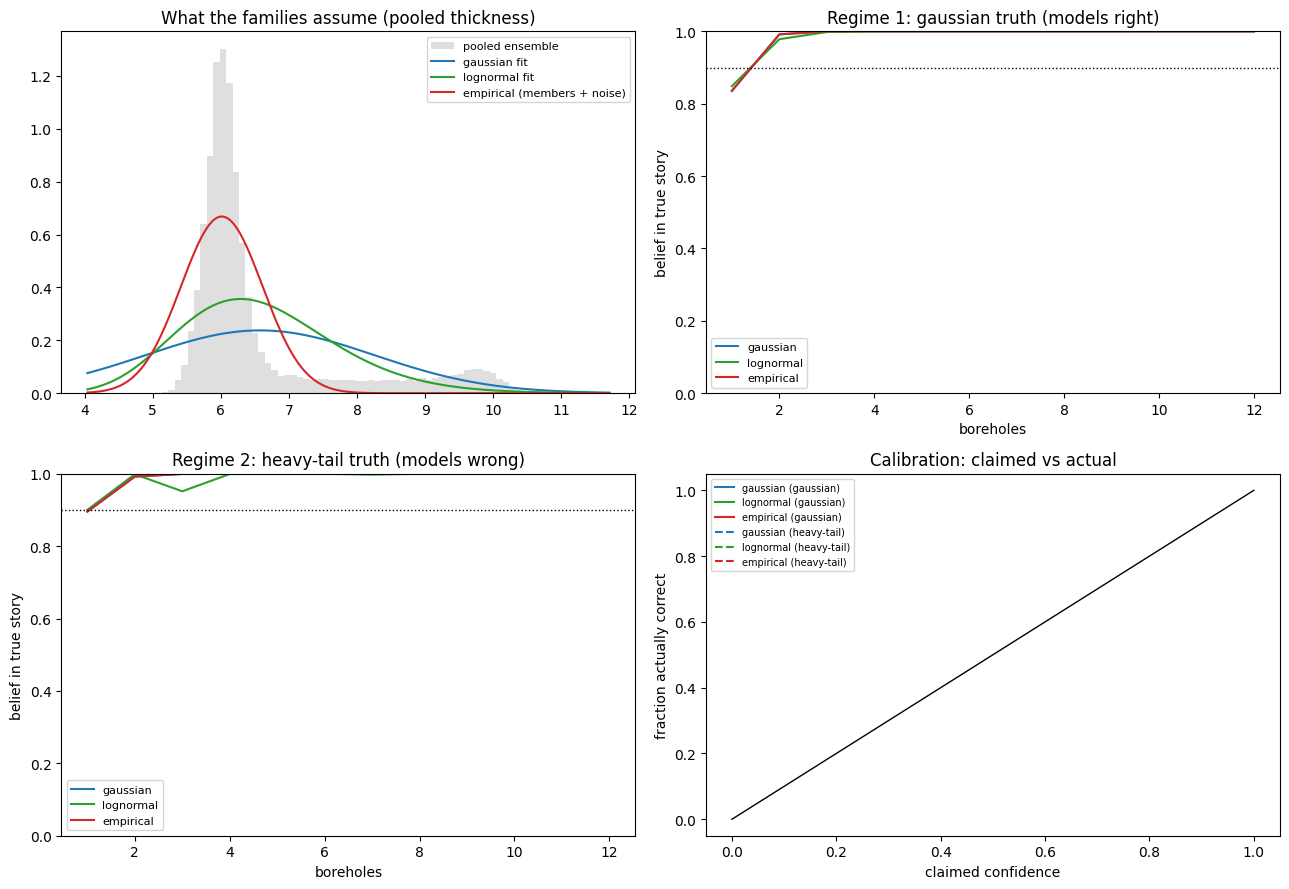

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (0,0) WHAT differs: densities fitted to the pooled thickness sample
# (trough + off-trough cells mixed - the null's world). The empirical
# mixture keeps the two modes; the parametric families smear them.
pool = np.concatenate([m[0].ravel() for ens in ensembles for m in ens])
xs = np.linspace(pool.min() - 1, pool.max() + 1, 400)
mu, sd = pool.mean(), pool.std()
ax[0, 0].hist(pool, bins=60, density=True, alpha=0.25, color='grey',
              label='pooled ensemble')
ax[0, 0].plot(xs, norm.pdf(xs, mu, sd + NOISE_T), color='tab:blue',
              label='gaussian fit')
lm, ls = np.log(pool).mean(), np.sqrt(np.log(pool).var() + (NOISE_T / mu)**2)
ax[0, 0].plot(xs, np.exp(norm.logpdf(np.log(xs), lm, ls)) / xs,
              color='tab:green', label='lognormal fit')
sub = pool[::20]
ax[0, 0].plot(xs, np.exp(norm.logpdf(xs[:, None], sub[None, :], NOISE_T)).mean(1),
              color='tab:red', label='empirical (members + noise)')
ax[0, 0].set_title('What the families assume (pooled thickness)')
ax[0, 0].legend(fontsize=8)

# (0,1) and (1,0): belief in the TRUE story, averaged over trials.
# Near-identical lines in regime 1 are the (expected) null result;
# regime 2 is where thin tails should whipsaw.
for a, (store, key, title) in zip(
        [ax[0, 1], ax[1, 0]],
        [(hist_g, 'gaussian', 'Regime 1: gaussian truth (models right)'),
         (hist_h, 'heavy-tail', 'Regime 2: heavy-tail truth (models wrong)')]):
    for fam, color in zip(FAMILIES, ('tab:blue', 'tab:green', 'tab:red')):
        H = np.stack([store[(key, tt, fam)][:, tt % 4]
                      for tt in range(ABL_TRIALS)])
        a.plot(range(1, ABL_HOLES + 1), H.mean(0), color=color, label=fam)
    a.axhline(DECISION_CONF, color='k', linestyle=':', linewidth=1)
    a.set_title(title)
    a.set_xlabel('boreholes')
    a.set_ylabel('belief in true story')
    a.set_ylim(0, 1)
    a.legend(fontsize=8)

# (1,1) Calibration: claimed confidence vs empirical correctness.
# Points BELOW the diagonal = overconfidence = fabricated certainty.
for (regime, ls_style) in [('gaussian', '-'), ('heavy-tail', '--')]:
    for fam, color in zip(FAMILIES, ('tab:blue', 'tab:green', 'tab:red')):
        s = cal[(cal.regime == regime) & (cal.family == fam)
                & (cal.claimed >= 0.25)]
        binned = s.groupby(pd.cut(s.claimed, [0.25, 0.5, 0.75, 0.9, 1.0],
                                  include_lowest=True),
                           observed=True).agg(claimed=('claimed', 'mean'),
                                              correct=('correct', 'mean'),
                                              n=('correct', 'size'))
        binned = binned[binned.n >= 5]
        ax[1, 1].plot(binned.claimed, binned.correct, ls_style, color=color,
                      label=f'{fam} ({regime})', markersize=5)
ax[1, 1].plot([0, 1], [0, 1], color='k', linewidth=1)
ax[1, 1].set_title('Calibration: claimed vs actual')
ax[1, 1].set_xlabel('claimed confidence')
ax[1, 1].set_ylabel('fraction actually correct')
ax[1, 1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Step 9c - how to read the results

- Panel (0,0) shows the shape question in miniature: the pooled predictive is bimodal (trough and off-trough cells), the empirical family preserves that, the parametric families smear it.
- The trajectory panels: near-identical in regime 1 (shape is a rounding error when the assumption is right), divergent in regime 2 - expect the gaussian family's true-story belief to whipsaw on spike readings, and the lognormal to move less.
- The calibration panel is the fabricated-certainty verdict: regime-1 points on the diagonal (claimed 90 percent = actually right 90 percent); regime-2 points dropping below the diagonal for thin-tailed families is the whole result.
- The printed table carries the numbers: accuracy, holes-to-decision, confidently-wrong hole counts (the whiplash metric), leadership flips.

README framing that writes itself: on synthetic Gaussian worlds the likelihood family barely matters; the moment the world's tails are heavier than the model's, thin-tailed scoring converts surprise into false certainty - and the only family that cannot lie about shape is the one with no shape at all.

## Step 10 - falsification experiment

Set the truth OUTSIDE the hypothesis set: a graben at a different orientation, with a grade mean between the two domains. If the null-minus-human line crosses zero, the planner has detected that every human story is false. With the noise term fixed in Step 4, this comparison is an honest likelihood ratio: expect the null to win once holes land off the hypothesized graben axis.

In [22]:
# Truth outside the story set: a graben with a different orientation and a
# grade mean between the two geochemical domains. Every story is wrong;
# the question is whether the scoreboard notices.
novel = {'name': 'novel graben', 'graben': True, 'slope': -0.9,
         't_mean': 6.0, 'g_mean': 0.9}
r_novel = run_trial(novel, ensembles, falsify=True, seed=42)
print('null minus human log-likelihood (first 12 holes):')
print([round(x, 1) for x in r_novel['null_hist'][:12]])

null minus human log-likelihood (first 12 holes):
[np.float64(-0.0), np.float64(2.9)]


## Step 11 - visualization

The 3D surface is the true grade field with the drill path overlaid; the curves show the posterior converging and the falsification signal. plotly was imported in Step 1 so any install problem surfaced there.

In [23]:
T_true, G_true = r_novel['truth']
ii, jj = np.meshgrid(np.arange(GRID), np.arange(GRID), indexing='ij')

fig = go.Figure(data=[go.Surface(
    z=G_true, x=ii, y=jj,
    colorscale='Turbo',
    cmin=float(G_true.min()), cmax=float(G_true.max()),
    opacity=1.0,
    contours=dict(z=dict(
        show=True,
        usecolormap=False,       # static contour lines take ONE flat color:
        color='black',           # black, not colormap-tinted
        width=1.5,
        project_z=True,          # black projections on the backdrop too
        size=0.02,
        highlight=True,          # the HOVER contour is a separate line:
        highlightcolor='white',  # white pops against Turbo + black lines
        highlightwidth=3,
    )),
    lighting=dict(ambient=0.45, diffuse=0.85, specular=0.05,
                  roughness=0.6, fresnel=0.1),
    lightposition=dict(x=100, y=200, z=50),
)])

di = [c[0] for c in r_novel['drilled']]
dj = [c[1] for c in r_novel['drilled']]
dz = [G_true[i, j] for (i, j) in r_novel['drilled']]
# Drill path in hole order. If red gets lost against Turbo's reds, use black.
fig.add_trace(go.Scatter3d(x=di, y=dj, z=dz,
                           mode='markers+lines',
                           marker=dict(size=6, color='red'),
                           line=dict(color='red', width=3),
                           name='drill path'))
fig.update_layout(scene=dict(
        xaxis=dict(title='x', gridcolor='black', gridwidth=1),
        yaxis=dict(title='y', gridcolor='black', gridwidth=1),
        zaxis=dict(title='grade', gridcolor='black', gridwidth=1),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1.1),
        camera=dict(eye=dict(x=1.8, y=-1.3, z=0.75)),
    ),
    height=650,
    title='Truth grade field and EVOI drill path')
fig.show()

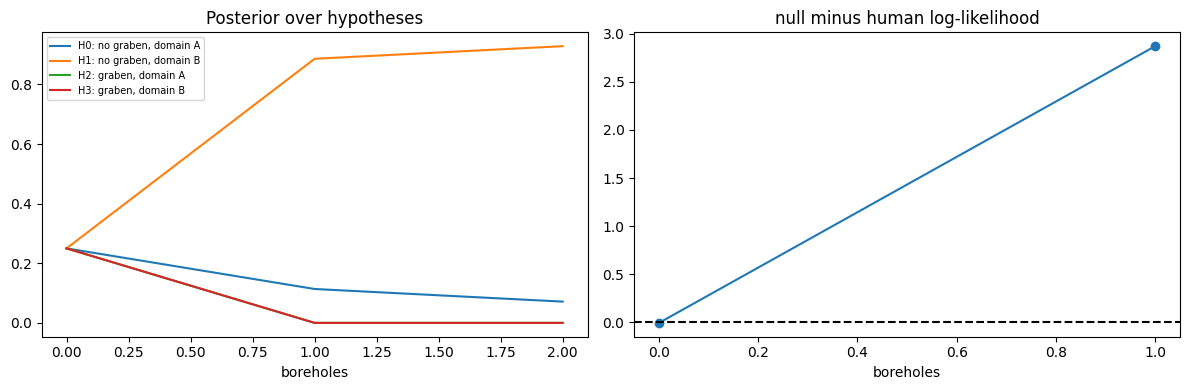

In [18]:
h = np.array(r_novel['hist'])
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4))
for k in range(len(HYPOTHESES)):
    ax2[0].plot(h[:, k], label=HYPOTHESES[k]['name'])
ax2[0].set_title('Posterior over hypotheses')
ax2[0].set_xlabel('boreholes')
ax2[0].legend(fontsize=7)
ax2[1].plot(r_novel['null_hist'], marker='o')
ax2[1].axhline(0, color='k', linestyle='--')
ax2[1].set_title('null minus human log-likelihood')
ax2[1].set_xlabel('boreholes')
plt.tight_layout()
plt.show()

## Step 12 - write results to BigQuery (setup checklist + code)

This step is optional: the notebook never requires GCP. If auth or the API is unavailable, the cell degrades gracefully and prints the dataframe.

### The two-minute path (recommended in Colab - no service account, no key file)

1. Open console.cloud.google.com and sign in with the same Google account you use in Colab.
2. If you have no project yet, the console offers to create one (top-left project picker - 'New project'). You need exactly ONE project. Note the **project ID** (lowercase with hyphens, e.g. popper-prospector-428119) - NOT the project display name, and NOT the project number. The code needs the ID. This mix-up is the single most common failure.
3. Enable the BigQuery API: type 'BigQuery API' into the console's top search bar (the omnibox finds everything; if a menu has been moved, search the label instead of hunting for it) and open the result, or go to 'APIs and Services' -> 'Library' -> search 'BigQuery API' -> click 'Enable'. On many personal projects it is already enabled - the button will be absent or gray.
4. That is all the permissions work: on a project you created, your account already has Owner/Editor IAM roles. When you run the cell, Colab opens an OAuth popup asking to grant access to your own account - click through, allow, done. No service account, no key JSON.
5. Set PROJECT_ID in the cell below to your project ID and run it. The cell creates the 'prospector' dataset itself (exists_ok=True) in the US multi-region - you do NOT need to click 'Create dataset' in BigQuery Studio. It loads the trials table, then prints a SQL summary.
6. Verify: console hamburger menu -> 'BigQuery' (under Analytics) -> your project -> 'prospector' -> 'trials'.


### Common errors and what they actually mean

- 'BigQuery API has not been used in project ... or it is disabled' -> enable the API (checklist step 3).
- 403 'access denied' on the LOAD job -> missing IAM permission on the PROJECT (not the dataset). On a project you created this should not happen; if it does: 'IAM and Admin' -> 'IAM' -> confirm your account has at least 'BigQuery Data Editor' AND 'BigQuery Job User' at project level.
- 'dataset ... not found' or region complaints -> should be impossible (the cell creates the dataset in US); if you made one by hand, name it exactly 'prospector' in the same project and the 'US' multi-region, or delete it and let the cell do it.
- 'Default credentials not found' OUTSIDE Colab -> use the service-account path below.

### Service-account path (only for Cloud Run jobs / local / scheduled runs - not Colab)

1. 'IAM and Admin' -> 'Service Accounts' -> 'Create service account'. Name it (e.g. prospector-writer).
2. Grant roles: 'BigQuery Data Editor' (read/write tables) and 'BigQuery Job User' (run load/query jobs). Both live under the 'BigQuery' category in the role picker; type the name if the picker is slow.
3. Open the account -> 'Keys' tab -> 'Add key' -> 'Create new key' -> JSON. A .json file downloads.
4. Point the environment at it BEFORE constructing the client: os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/path/to/key.json'. The BigQuery client picks it up automatically through the Application Default Credentials chain.
5. Never commit the key. Treat it like a password; rotate it in the same Keys tab if it leaks.

Reference links: console.cloud.google.com - cloud.google.com/bigquery - cloud.google.com/bigquery/docs/sandbox

In [19]:
PROJECT_ID = 'your-project-id'  # <-- set this (the ID, lowercase-with-hyphens)

try:
    # Colab-native OAuth (no service account, no key file: the popup
    # grants your own account, which already owns the project). A no-op
    # outside Colab or when ADC is already set via gcloud or a key.
    try:
        from google.colab import auth
        auth.authenticate_user()
    except Exception:
        pass

    from google.cloud import bigquery
    from IPython.display import display
    client = bigquery.Client(project=PROJECT_ID)

    # Create the dataset if missing (exists_ok makes re-runs safe).
    # Location US: keep it, or region-mismatch errors will hunt you.
    client.create_dataset(bigquery.Dataset(f'{PROJECT_ID}.prospector'),
                          exists_ok=True)

    table_id = f'{PROJECT_ID}.prospector.trials'
    # WRITE_TRUNCATE: re-running REPLACES the table. The default (append)
    # would silently stack duplicate trials into the SQL averages below.
    job_config = bigquery.LoadJobConfig(write_disposition='WRITE_TRUNCATE')
    job = client.load_table_from_dataframe(df, table_id, job_config=job_config)
    job.result()
    print('loaded', len(df), 'rows into', table_id)

    sql = f'''
        SELECT truth,
               AVG(pomdp_decision) AS avg_planner_holes,
               AVG(grid_decision)   AS avg_grid_holes,
               AVG(correct)         AS accuracy
        FROM `{table_id}`
        GROUP BY truth
        ORDER BY truth
    '''
    display(client.query(sql).to_dataframe())
except Exception as e:
    print('BigQuery skipped:', e)
    print('If this is an auth/permission error, see the checklist in the')
    print('Step 12 markdown: enable the BigQuery API, use the project ID')
    print('(not the name), and confirm IAM roles on the project.')
    print()
    print(df.groupby('truth').mean(numeric_only=True))

BigQuery skipped: ("Failed to retrieve http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/?recursive=true from the Google Compute Engine metadata service. Status: 404 Response:\nb''", <google.auth.transport.requests._Response object at 0x7de360102c40>)
If this is an auth/permission error, see the checklist in the
Step 12 markdown: enable the BigQuery API, use the project ID
(not the name), and confirm IAM roles on the project.

                         trial  pomdp_holes  pomdp_decision  grid_decision  \
truth                                                                        
H0: no graben, domain A    4.0          1.0             1.0            3.0   
H1: no graben, domain B    5.0          1.0             1.0       3.333333   
H2: graben, domain A       6.0          1.0             1.0            3.0   
H3: graben, domain B       7.0          1.0             1.0            3.0   

                         correct  
truth                         

## Step 13 - limitations and next steps

**What this honestly is:** a reduced, transparent version of the decision loop, not a reproduction of their results. Also: simulation, not geology - the numbers it produces are properties of an invented world (the paper's own experiments are synthetic too; a drilling policy can only be scored where the answer key is free).

**Simplifications to state plainly in any write-up:**
- Belief covers hypotheses only, not domain geometry - no hierarchical sampling, no MCMC. The notebook is Bayesian at the top layer and frozen below it.
- Planner is myopic (one-step), not a solved POMDP; and the paper's objective is economic reward with information gain falling out of it - ours hard-codes information gain, which is the sharpest philosophical divergence.
- Fixed assumptions, the full inventory: likelihood SHAPE assumed Gaussian (tested in Step 9c); instrument noise assumed KNOWN and identical everywhere; geological width fixed by construction (Step 2 constants that no drilling ever re-estimates); readings treated as conditionally independent given a story - the likelihood sees point values, not spatial patterns (the paper partially escapes via kriging); hypothesis parameters exact; domain membership unobserved (the paper observes it directly).
- Calibration promise: DECISION_CONF = 0.90 means '90 percent sure' only if everything above holds. Confidence measures internal consistency, not correctness - which is why the null scoreboard exists.
- human_loglik re-weights its mixture with the live posterior (Step 7) - mild double-dipping that a strict Popper test would avoid.
- Step 9c's empirical family is inert on Gaussian ensembles - shape-freedom only pays off on real (non-Gaussian) data.

**Natural next steps, in priority order:**
1. Real-data mode: slot the free, public-domain Walker Lake exhaustive dataset (about 78,000 real points on a 260x300 grid, plus a 470-sample sparse subset) in exactly where sample_field sits. Hypotheses become geostatistical models fitted to the sparse subset; ensembles come from conditional simulation (Paper 2's variance restoration, for real); the exhaustive grid becomes the oracle. Cost: 0 dollars; about a weekend.
2. Restore the geometry layer: sample graben location/width with a particle filter (one day).
3. Add the direct domain observation (trivial), and swap myopic EVOI for a two-step lookahead with an economic reward - the real work, where you stop being adjacent to SARSOP territory and start inhabiting it.

## Appendix - the whole thing in one paragraph

The loop is a four-way bet updated hole by hole; drilling is the act of buying information where it is cheapest relative to how much it can move the bet; and the falsification scoreboard is a second opinion from someone who believes nothing. No gradients, no training, no variational anything - the statistics are deliberately boring, and the interesting part is only where the randomness lives: in the world (aleatoric - the ensembles carry it), in the instrument (noise, convolved into every bell curve), in the planner (small-sample Monte Carlo error, refreshed each hole, reducible with compute), and - fatally, if you get it wrong - in the spread you claim for each story. Noise averages out across holes; wrongness compounds. Everything else in this notebook is bookkeeping around those two sentences.